# 📊 Understanding Co-Occurrence in NLP

### 🔍 What is Co-Occurrence?
Co-occurrence measures **how often two words appear close to each other** within a specific window of text (called a context window). 

If two words frequently appear together, it implies they share a strong semantic relationship or context. For example:
* **"Ice"** and **"Cream"** co-occur frequently.
* **"Deep"** and **"Learning"** co-occur frequently.
* **"Ice"** and **"Learning"** rarely co-occur.

---

### 🪟 The Concept of a "Context Window"
We don't just look at words touching each other; we look at a small neighborhood around a target word.

**Example Sentence:**  
> *"The quick brown fox jumps over the lazy dog."*

If our **Target Word** is **"fox"** and our **Window Size is 2**, we look 2 words to the left and 2 words to the right:

$$\text{[quick, brown]} \leftarrow \mathbf{\text{fox}} \rightarrow \text{[jumps, over]}$$

In this specific window, **fox** co-occurs once with: *quick, brown, jumps,* and *over*.

---

### 🕸️ What is a Co-Occurrence Matrix?
A **Co-Occurrence Matrix** is a symmetric square table where both rows and columns represent the unique words in your vocabulary ($V$). 

* Each cell $(i, j)$ contains a count ($X_{ij}$) of how many times word $i$ and word $j$ appeared together inside the context window across your entire text corpus.

#### 📝 Simple Walkthrough:
Let's build a matrix for these two short sentences with a **Window Size of 1** (only immediate neighbors):
1. *"I love NLP"*
2. *"I love Python"*

| | I | love | NLP | Python |
| :--- | :---: | :---: | :---: | :---: |
| **I** | 0 | 2 | 0 | 0 |
| **love** | 2 | 0 | 1 | 1 |
| **NLP** | 0 | 1 | 0 | 0 |
| **Python** | 0 | 1 | 0 | 0 |

* **Why is `(I, love) = 2`?** Because "I" and "love" are neighbors in both sentences.
* **Why is `(love, NLP) = 1`?** Because they are neighbors only in the first sentence.

---

### 💡 Why does GloVe care about Co-Occurrence?
GloVe (Global Vectors for Word Representation) is built entirely on the mathematical insight that **ratios of co-occurrence probabilities** capture meaning.

Instead of just looking at raw counts ($X_{ij}$), GloVe looks at the probability ($P_{ik}$) of word $i$ appearing near word $k$:

$$P_{ik} = \frac{X_{ik}}{X_i}$$

#### 🧠 The Famous GloVe Intuition Example:
Let's look at the target words **$i$ = "ice"** and **$j$ = "steam"**, and see how they co-occur with a random probe word **$k$**:

1. **If $k$ = "solid"**: It co-occurs a lot with *ice*, but rarely with *steam*. 
   * $\frac{P(\text{solid} \mid \text{ice})}{P(\text{solid} \mid \text{steam})} = \mathbf{\text{Large Number}}$
2. **If $k$ = "gas"**: It co-occurs rarely with *ice*, but a lot with *steam*.
   * $\frac{P(\text{gas} \mid \text{ice})}{P(\text{gas} \mid \text{steam})} = \mathbf{\text{Small Number}}$
3. **If $k$ = "water"**: It co-occurs frequently with both.
   * $\frac{P(\text{water} \mid \text{ice})}{P(\text{water} \mid \text{steam})} \approx \mathbf{1}$
4. **If $k$ = "fashion"**: It co-occurs rarely with both.
   * $\frac{P(\text{fashion} \mid \text{ice})}{P(\text{fashion} \mid \text{steam})} \approx \mathbf{1}$

By training word vectors ($w_i, w_j$) so that their dot product mimics these log co-occurrence patterns ($\log X_{ij}$), GloVe forces words with similar properties to end up close to each other in vector space!


In [1]:
#### Build a co-occurence matrix

import numpy as np
from collections import defaultdict
import itertools
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import re

C:\Users\angaj\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\angaj\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
### Define a large corpus
corpus = [
    "Natural language processing enables computer to understand humman language",
    "Machine learning part of Aritficial inteliginece",
    "Deep learning is a subset of Machine learining",
    "Text data can be use for sentiment analysis",
    "Word embedding are usefull for NLP applications.",
    "Sentimet analysis detiermines if sentence is positive and negative"
]

In [3]:
### Clean and tokenize 
def preprocess(sentence):
    return re.sub(r"[^a-zA-Z]", " ", sentence).lower().split()


tokenized = [preprocess(sentence) for sentence in corpus]
tokenized


[['natural',
  'language',
  'processing',
  'enables',
  'computer',
  'to',
  'understand',
  'humman',
  'language'],
 ['machine', 'learning', 'part', 'of', 'aritficial', 'inteliginece'],
 ['deep', 'learning', 'is', 'a', 'subset', 'of', 'machine', 'learining'],
 ['text', 'data', 'can', 'be', 'use', 'for', 'sentiment', 'analysis'],
 ['word', 'embedding', 'are', 'usefull', 'for', 'nlp', 'applications'],
 ['sentimet',
  'analysis',
  'detiermines',
  'if',
  'sentence',
  'is',
  'positive',
  'and',
  'negative']]

In [4]:
### build vocabulary
vocab = sorted(set(itertools.chain(*tokenized)))
vocab_size = len(vocab)

word2id = {word: i for i, word in enumerate(vocab)}
id2word = {i: word for word, i in word2id.items()}

In [33]:
def build_co_occurrence_matrix(tokenized_corpus, vocab_size, word2id, window_size=2):
    cooccurrence_matrix = np.zeros((vocab_size, vocab_size), dtype=np.float64)
    
    for sentence in tokenized_corpus:
        sentence_ids = [word2id[word] for word in sentence]
        for idx, word_id in enumerate(sentence_ids):
            start = max(idx + window_size, 0)
            end = min(idx - window_size + 1, len(sentence_ids))
            
            # Iterate through words in the context window
            for context_idx in range(start, end):
                if context_idx != idx:
                    context_id = sentence_ids[context_idx]
                    cooccurrence_matrix[word_id , context_id] += 1 
                
    return cooccurrence_matrix

In [35]:
matrix = build_co_occurrence_matrix(tokenized, vocab_size, word2id, window_size=2)
print(matrix)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [36]:
### initialize glov parameters

np.random.seed(42)
embedding_dims = 50

w = np.random.randn(vocab_size, embedding_dims)/np.sqrt(embedding_dims)
w_tilde = np.random.randn(vocab_size, embedding_dims) / np.sqrt(embedding_dims)
biases_w = np.zeros(vocab_size)
biases_tilde = np.zeros(vocab_size)

non_zero_indices = np.nonzero(matrix)

### weighing

def weighting_func(matrix, x_max=100, alpha=0.75):
    f_x = np.where(matrix < x_max, (matrix/x_max) ** alpha, 1.0)
    return f_x


weights = weighting_func(matrix)

In [37]:
### train glove embeddings

import numpy as np

# --- Hyperparameters & Initialization placeholders ---
learning_rate = 0.05  
num_epochs = 100

for epoch in range(num_epochs):
    total_loss = 0
    
    for i, j in zip(*non_zero_indices):
        # 1. Access matrix elements with proper 2D indexing
        x_ij = matrix[i, j] 
        w_i = w[i]
        w_j = w_tilde[j]
        b_i = biases_w[i]
        b_j = biases_tilde[j]
        weight = weights[i, j]
        
        # 2. Forward pass
        inner_product = np.dot(w_i, w_j)
        log_x_ij = np.log(x_ij)
        diff = (inner_product + b_i + b_j - log_x_ij)
        loss = weight * (diff ** 2)
        total_loss += loss
        
        grad_w_i = weight * diff * w_j
        grad_w_j = weight * diff * w_i
        grad_b_i = weight * diff
        grad_b_j = weight * diff
        
        
        w[i] -= learning_rate * grad_w_i
        w_tilde[j] -= learning_rate * grad_w_j
        biases_w[i] -= learning_rate * grad_b_i
        biases_tilde[j] -= learning_rate * grad_b_j  
        
    if (epoch + 1) % 10 == 0:
        print(f"Epoch: {epoch + 1}/{num_epochs}, Loss: {total_loss:.4f}")


Epoch: 10/100, Loss: 0.0000
Epoch: 20/100, Loss: 0.0000
Epoch: 30/100, Loss: 0.0000
Epoch: 40/100, Loss: 0.0000
Epoch: 50/100, Loss: 0.0000
Epoch: 60/100, Loss: 0.0000
Epoch: 70/100, Loss: 0.0000
Epoch: 80/100, Loss: 0.0000
Epoch: 90/100, Loss: 0.0000
Epoch: 100/100, Loss: 0.0000


In [38]:
embeddings = w + w_tilde

In [39]:
def most_similar(word, embeddings, word2id, id2word, top_n=5):
    idx = word2id[word]
    vec = embeddings[idx].reshape(1, -1)
    sims = cosine_similarity(vec, embeddings)[0]
    top_ids = sims.argsort()[::-1][1: top_n+1]
    return [(id2word[i], sims[i]) for i in top_ids]

print(most_similar("language", embeddings, word2id, id2word))

[('humman', 0.2179777232300656), ('aritficial', 0.1756205787612076), ('processing', 0.1467721095772966), ('sentiment', 0.1429373680507815), ('be', 0.10433964416080946)]


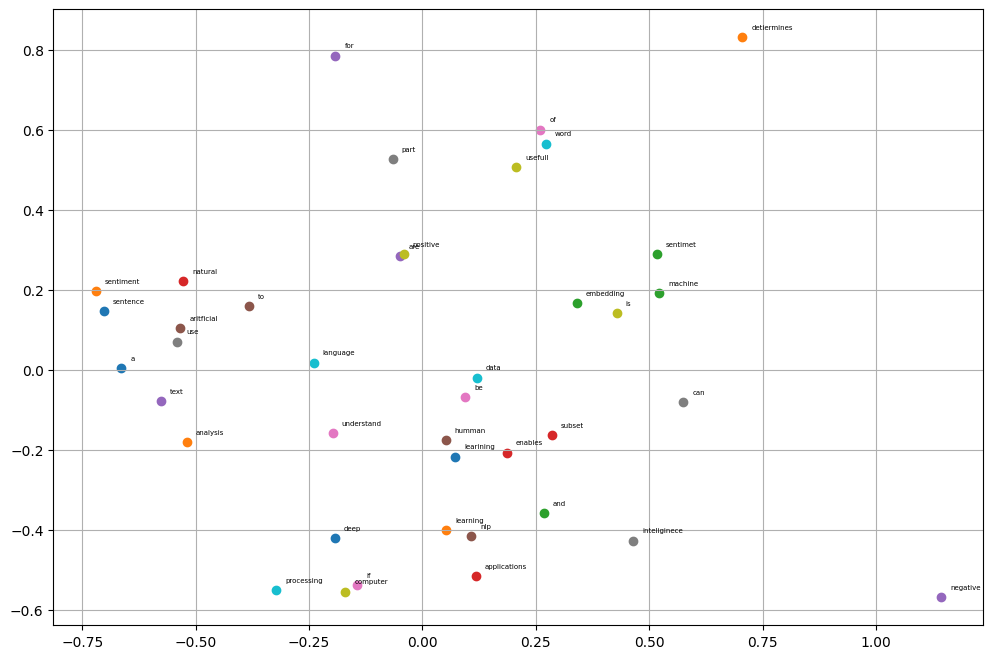

In [48]:
## Visualize embeddings

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(12, 8))
for i, word in id2word.items():
    x, y = reduced[i]
    plt.scatter(x, y)
    plt.text(x + 0.02, y+ 0.02, word, fontsize=5)


plt.grid()
plt.show()